# 📊 Análise de Ações - Itaú Unibanco (ITUB4)

**Autor:** Nicolas Maximillian Buzatto de Gomes Leal
**Objetivo:** Análise exploratória e financeira das ações do Itaú Unibanco (ITUB4), com indicadores técnicos, métricas de risco e comparativo com o IBOVESPA e a Selic.

---

## Sumário
1. [Importações e Configurações](#1)
2. [Coleta de Dados](#2)
3. [Análise Exploratória](#3)
4. [Indicadores Técnicos](#4)
5. [Métricas de Risco](#5)
6. [Comparativo com Benchmarks](#6)
7. [Conclusões](#7)

## 1. Importações e Configurações <a id='1'></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore') #Serve para ocultar mensgaens de avisos(warnings) que o python ou bibliotecas exibem durante a execução

# Configuração visual dos gráficos
plt.rcParams['figure.figsize'] = (14, 6)#Defini o tamanho pdrão da figura, largura= 14, Altura = 6
plt.rcParams['axes.grid'] = True # Ativa a garde nno fundo do gráfico.
plt.rcParams['grid.alpha'] = 0.3 # Define a transparência da grade, de 0 (invisível) até 1 (bem forte).
plt.rcParams['axes.spines.top'] = False # deixam o gráfico com estilo mais moderno e limpo
plt.rcParams['axes.spines.right'] = False # deixam o gráfico com estilo mais moderno e limpo

# Cores institucionais Itaú
COR_ITAU   = '#003D7A'   # azul Itaú
COR_IBOV   = '#FF6B00'   # laranja
COR_SELIC  = '#28A745'   # verde
COR_ALERTA = '#EC1C24'   # vermelho

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 2. Coleta de Dados <a id='2'></a>

Utilizei a biblioteca `yfinance` para baixar o histórico de preços diretamente da API do Yahoo Finance.  
Os dados incluem: preço de abertura, máxima, mínima, fechamento, volume e dividendos ajustados.

In [2]:
# --- Parâmetros da coleta ---
TICKER_ITUB = 'ITUB4.SA' #Ação do Itaú na bolsa brasileira
TICKER_IBOV = '^BVSP' #Indice Ibovespa
DATA_INICIO = '2021-01-01'
DATA_FIM    = '2025-12-31'

print(f'📥 Baixando dados de {DATA_INICIO} até {DATA_FIM}...') # Exibe mensagem informando o periodo

# Download dos dados
# Baixa os dados históricos da ITUB4.
# auto_adjust=True ajusta os preços históricos para refletir eventos corporativos,
# como dividendos e desdobramentos, tornando a série mais adequada para análise de retornos.
itub4 = yf.download(TICKER_ITUB, start=DATA_INICIO, end=DATA_FIM, auto_adjust=True) # Faz o download da abertura, máxima, mínima, fechamento e volume, 'auto_adjust=True' serve para ajustar os preços automaticamente.
# Baixa os dados históricos do Ibovespa com os preços ajustados.
ibov  = yf.download(TICKER_IBOV, start=DATA_INICIO, end=DATA_FIM, auto_adjust=True) # Faz o download da abertura, máxima, mínima, fechamento e volume, 'auto_adjust=True' serve para ajustar os preços automaticamente.

# Flatten de colunas multi-level (yfinance >= 0.2.x retorna MultiIndex)
if isinstance(itub4.columns, pd.MultiIndex):
    itub4.columns = itub4.columns.get_level_values(0)
if isinstance(ibov.columns, pd.MultiIndex):
    ibov.columns = ibov.columns.get_level_values(0)

print(f'✅ ITUB4: {len(itub4)} pregões carregados')
print(f'✅ IBOVESPA: {len(ibov)} pregões carregados')

📥 Baixando dados de 2021-01-01 até 2025-12-31...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

✅ ITUB4: 1246 pregões carregados
✅ IBOVESPA: 1246 pregões carregados


## 3. Análise Exploratória <a id='3'></a>

In [3]:
# --- Verificação de qualidade dos dados ---
print('=== ITUB4 — Verificação de dados nulos ===')
print(itub4.isnull().sum())# Verificar se tem dados nulos e trazer a quantidade deles caso tenha.

# Preencher eventuais lacunas com o valor do dia anterior (forward fill), usado para preencher o último preço para possieis Nan em casos de fins de semanas e feriados
itub4 = itub4.ffill()
ibov  = ibov.ffill()

print('\n=== Primeiros registros ===')
itub4[['Open', 'High', 'Low', 'Close', 'Volume']].head()

=== ITUB4 — Verificação de dados nulos ===
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

=== Primeiros registros ===


Price,Open,High,Low,Close,Volume
Date,,,,,
2021-01-04,20.108541,20.114828,19.391727,19.429453,35517057
2021-01-05,19.322559,19.530058,18.970440,19.303696,32007023
2021-01-06,19.479750,20.158836,19.360279,19.869596,48789132
2021-01-07,19.901030,20.787616,19.806712,20.642996,52265063
2021-01-08,20.705885,21.026566,20.391492,20.636719,59519322


In [4]:
# --- Estatísticas descritivas ---
print('=== Estatísticas Descritivas — Preço de Fechamento ITUB4 ===')
print(itub4['Close'].describe().round(2))

=== Estatísticas Descritivas — Preço de Fechamento ITUB4 ===
count    1246.00
mean       22.05
std         6.05
min        13.64
25%        17.42
50%        19.62
75%        25.54
max        38.90
Name: Close, dtype: float64


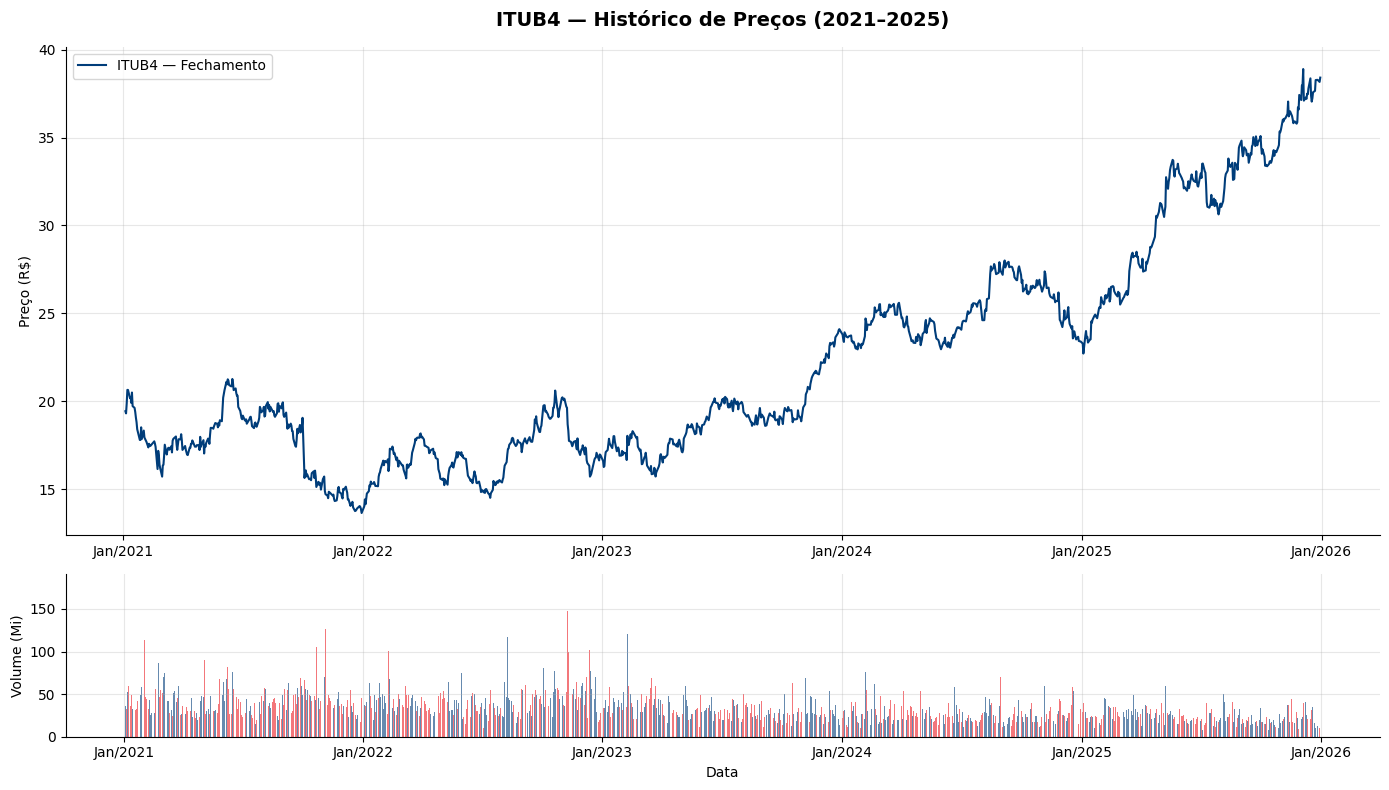


💡 Nota contábil: O volume representa a liquidez do papel — fundamental para análise de risco de mercado.


In [5]:
# --- Gráfico 1: Histórico de preços e volume ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(itub4.index, itub4['Close'], color=COR_ITAU, linewidth=1.5, label='ITUB4 — Fechamento')
ax1.set_title('ITUB4 — Histórico de Preços (2021–2025)', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Preço (R$)')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

# Volume em barras com cor condicional (alta = azul, baixa = vermelho)
cores_vol = [COR_ITAU if r >= 0 else COR_ALERTA 
             for r in itub4['Close'].pct_change().fillna(0)]
ax2.bar(itub4.index, itub4['Volume'] / 1e6, color=cores_vol, alpha=0.6, width=1)
ax2.set_ylabel('Volume (Mi)')
ax2.set_xlabel('Data')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.tight_layout()
plt.savefig('c:/Users/nicol/analise-itau/imagens/grafico_preco_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Nota contábil: O volume representa a liquidez do papel — fundamental para análise de risco de mercado.')

## 4. Indicadores Técnicos <a id= '4'></a>

Indicadores técnicos são ferramentas estatísticas derivadas de preço e volume utilizadas para identificar tendências e pontos de entrada/saída em ativos financeiros.

In [6]:
# --- Médias Móveis Simples ---
# MM são usadas para identificar tendências, elas suavizam o preço para você enxergar a direção geral. Preços acima da média são tendências altas e preço abaixo são tendências de baixa. MM curta cruzando acima da longa → sinal de compra (Golden Cross), MM curta cruzando abaixo → sinal de venda (Death Cross)
# MM20: tendência de curto prazo (~1 mês útil)
# MM50: tendência de médio prazo (~2,5 meses)
# MM200: tendência de longo prazo (~1 ano)
# .rolling(window=20) pega os últimos 20, 50 e 200 dias do fechamento
# .mean() -> calcula a média
itub4['MM_20']  = itub4['Close'].rolling(window=20).mean()# Cria uma nova coluna com a média dos últimos 20(curto prazo) dias do fechamento
itub4['MM_50']  = itub4['Close'].rolling(window=50).mean()# Cria uma nova coluna com a média dos últimos 50(médio prazo) dias do fechamento
itub4['MM_200'] = itub4['Close'].rolling(window=200).mean()# Cria uma nova coluna com a média dos últimos 200(longo prazo) dias do fechamento

# --- Bandas de Bollinger (MM20 ± 2 desvios padrão) ---
# Serve para medir a volatilidade e possíveis extremos de preço
# O toque ou rompimento da banda pode indicar que o preço está em uma região relativamente extrema dentro da janela analisada, mas não deve ser interpretado isoladamente como sinal de compra ou venda.
# Quando toca a banda inferior → possível sobrevenda
# Bandas se abrindo → mercado volátil
# Bandas estreitas → possível explosão de preço vindo
std_20 = itub4['Close'].rolling(window=20).std() # Mede o quanto o preço varia (volatilidade)
itub4['BB_Superior'] = itub4['MM_20'] + (2 * std_20)
itub4['BB_Inferior'] = itub4['MM_20'] - (2 * std_20)

# --- RSI — Índice de Força Relativa (14 períodos) ---
# RSI > 70: ativo sobrecomprado (possível queda)
# RSI < 30: ativo sobrevendido (possível alta)
# RSI subindo → força compradora
# RSI caindo → força vendedora
# Divergência com preço → sinal importante
delta = itub4['Close'].diff()
ganho = delta.where(delta > 0, 0.0).rolling(14).mean()
perda = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
rs    = ganho / perda
itub4['RSI'] = 100 - (100 / (1 + rs))

print('✅ Indicadores técnicos calculados: MM20, MM50, MM200, Bollinger Bands, RSI')

✅ Indicadores técnicos calculados: MM20, MM50, MM200, Bollinger Bands, RSI


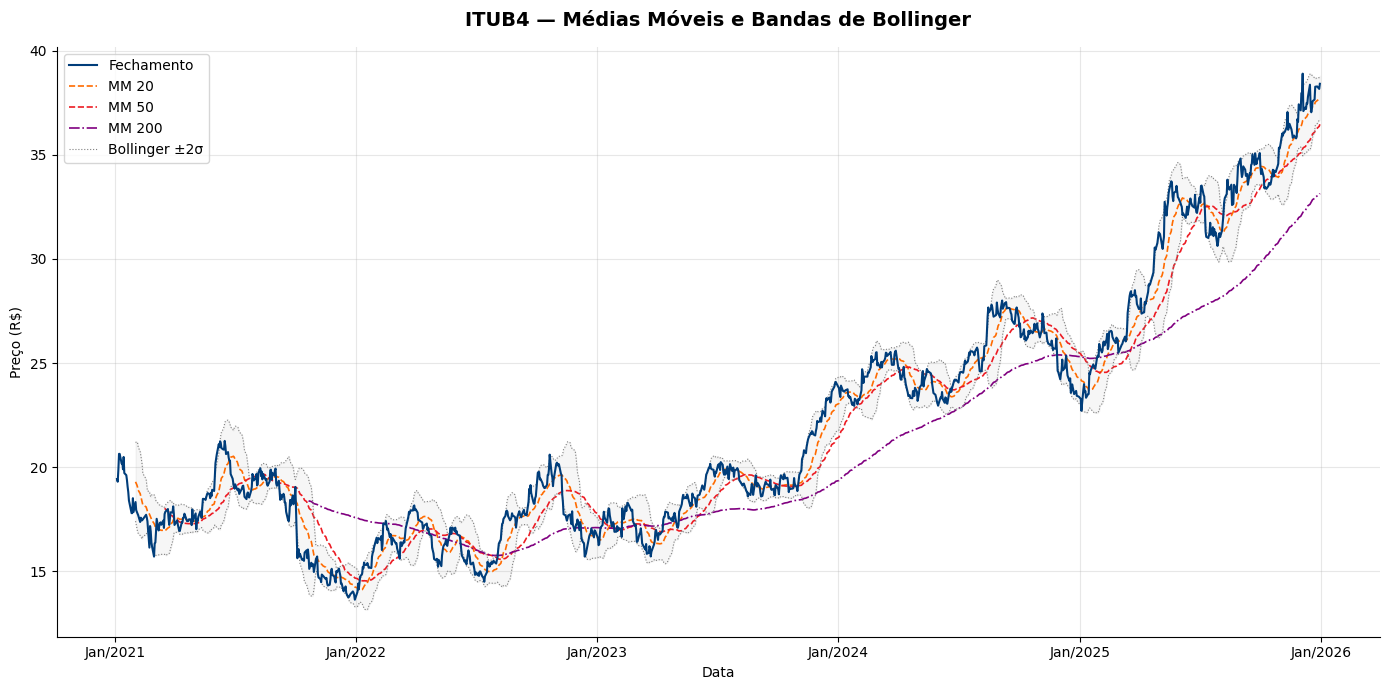

In [7]:
# --- Gráfico 2: Médias Móveis e Bollinger Bands ---
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(itub4.index, itub4['Close'],       color=COR_ITAU,   lw=1.5,  label='Fechamento',  zorder=3)
ax.plot(itub4.index, itub4['MM_20'],       color=COR_IBOV,   lw=1.2,  label='MM 20',       linestyle='--')
ax.plot(itub4.index, itub4['MM_50'],       color=COR_ALERTA, lw=1.2,  label='MM 50',       linestyle='--')
ax.plot(itub4.index, itub4['MM_200'],      color='purple',   lw=1.2,  label='MM 200',      linestyle='-.')
ax.plot(itub4.index, itub4['BB_Superior'], color='gray',     lw=0.8,  label='Bollinger ±2σ', linestyle=':')
ax.plot(itub4.index, itub4['BB_Inferior'], color='gray',     lw=0.8,  linestyle=':')
ax.fill_between(itub4.index, itub4['BB_Superior'], itub4['BB_Inferior'], alpha=0.07, color='gray')

ax.set_title('ITUB4 — Médias Móveis e Bandas de Bollinger', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Preço (R$)')
ax.set_xlabel('Data')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.tight_layout()
plt.savefig('c:/Users/nicol/analise-itau/imagens/grafico_medias_moveis.png', dpi=150, bbox_inches='tight')
plt.show()

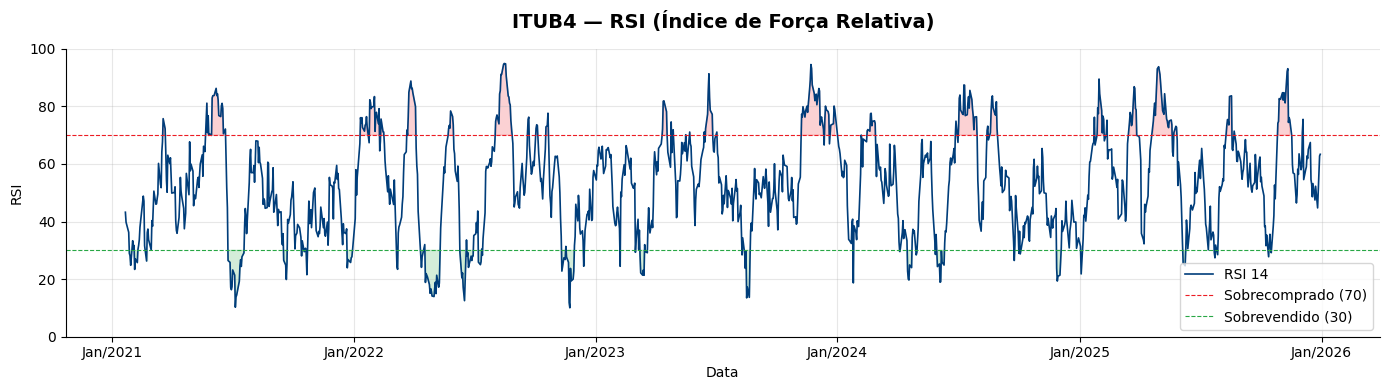

In [8]:
# --- Gráfico 3: RSI ---
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(itub4.index, itub4['RSI'], color=COR_ITAU, lw=1.2, label='RSI 14')
ax.axhline(70, color=COR_ALERTA, lw=0.8, linestyle='--', label='Sobrecomprado (70)')
ax.axhline(30, color=COR_SELIC,  lw=0.8, linestyle='--', label='Sobrevendido (30)')
ax.fill_between(itub4.index, itub4['RSI'], 70,
                where=(itub4['RSI'] >= 70), alpha=0.2, color=COR_ALERTA)
ax.fill_between(itub4.index, itub4['RSI'], 30,
                where=(itub4['RSI'] <= 30), alpha=0.2, color=COR_SELIC)

ax.set_ylim(0, 100)
ax.set_title('ITUB4 — RSI (Índice de Força Relativa)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('RSI')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.tight_layout()
plt.savefig('c:/Users/nicol/analise-itau/imagens/grafico_rsi.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Métrica de Risco <a id='5'></a>

Do ponto de vista contábil, o risco de mercado é a possibilidade de perda decorrente de variações adversas nos preços de mercado. As métricas abaixo são amplamente utilizadas por tesourarias e gestores de risco em instituições financeiras como o Itaú.

In [9]:
# --- Retorno diário e acumulado ---
# pct_change() = percentual de variação de um dia para o outro
# Ele compara o preço de hoje com o de ontem
itub4['Retorno_Diario']  = itub4['Close'].pct_change()
# 1 + retorno transforma em fato de crescimento
# .cumprod acumula crescimento composto
# - 1 volta para formato percentual
itub4['Retorno_Acum']    = (1 + itub4['Retorno_Diario']).cumprod() - 1 # .cumprod acumula crescimento composto, Multiplicando todos os valores sequencialmente

# --- Volatilidade anualizada (janela 21 dias) ---
# Multiplica por √252 para analizar (252 = pregões/ano), Qual instável e arriscado está o preço olhando o último mês, mas expresso em termos anuais
# .rolling(21) -> Pega os últimos 21 dias úteis para analise
itub4['Volatilidade_21d'] = itub4['Retorno_Diario'].rolling(21).std() * np.sqrt(252)

# --- VaR — Value at Risk (95% e 99%) ---
# Interpretação: com 95% de confiança, a perda diária não excederá X%
# Qual é a pior perda esperada em condições normais, com X% de confiança
var_95 = itub4['Retorno_Diario'].quantile(0.05) # Calcula o percentil 5%, pega o ponto onde estão os 5% piores retornos
var_99 = itub4['Retorno_Diario'].quantile(0.01) # Pega o percentil 1% Ou seja, o 1% piores dias

# --- Sharpe Ratio ---
# Mede o retorno por unidade de risco. Quanto maior, melhor.
# Selic referência: ~10.5% a.a. → 10.5/252 ao dia
SELIC_AA   = 0.105 # taxa selic ao ano
selic_dia  = SELIC_AA / 252 # taxa dselic diária
ret_medio  = itub4['Retorno_Diario'].mean()
vol_diaria = itub4['Retorno_Diario'].std()
sharpe     = (ret_medio - selic_dia) / vol_diaria * np.sqrt(252)

# --- Drawdown Máximo ---
# Maior queda do pico ao vale — métrica de risco de cauda muito usada por gestores
# Quanto o preço caiu a partir do seu valor máximo anterior
preco_maximo_hist = itub4['Close'].cummax()
itub4['Drawdown'] = (itub4['Close'] - preco_maximo_hist) / preco_maximo_hist 
max_drawdown = itub4['Drawdown'].min()

# --- Exibir resumo ---
print('=' * 50)
print('     RESUMO DE RISCO — ITUB4 (2021–2025)')
print('=' * 50)
print(f'  Retorno Total Acumulado : {itub4["Retorno_Acum"].iloc[-1]:>10.2%}')
print(f'  Volatilidade Média Anual: {itub4["Volatilidade_21d"].mean():>10.2%}')
print(f'  VaR Diário (95%)        : {var_95:>10.2%}')
print(f'  VaR Diário (99%)        : {var_99:>10.2%}')
print(f'  Sharpe Ratio            : {sharpe:>10.2f}')
print(f'  Drawdown Máximo         : {max_drawdown:>10.2%}')
print('=' * 50)

     RESUMO DE RISCO — ITUB4 (2021–2025)
  Retorno Total Acumulado :     97.70%
  Volatilidade Média Anual:     23.77%
  VaR Diário (95%)        :     -2.29%
  VaR Diário (99%)        :     -3.70%
  Sharpe Ratio            :       0.26
  Drawdown Máximo         :    -35.87%


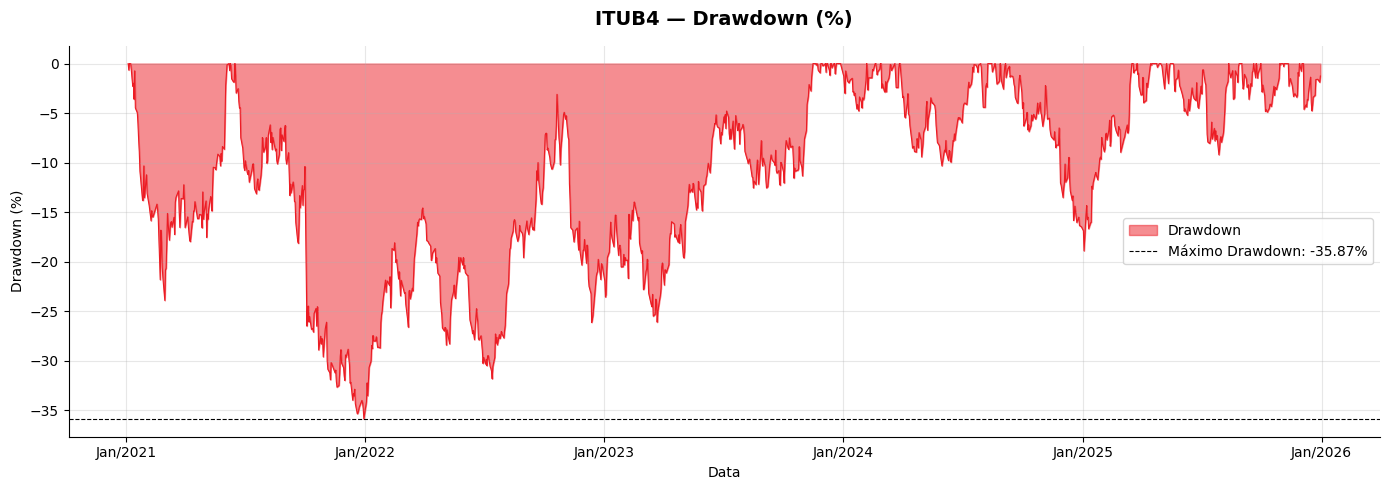


💡 Nota contábil: O drawdown máximo é análogo a uma perda máxima potencial — conceito central em relatórios de risco para o Bacen (RBAN, Nota Explicativa de Risco de Mercado).


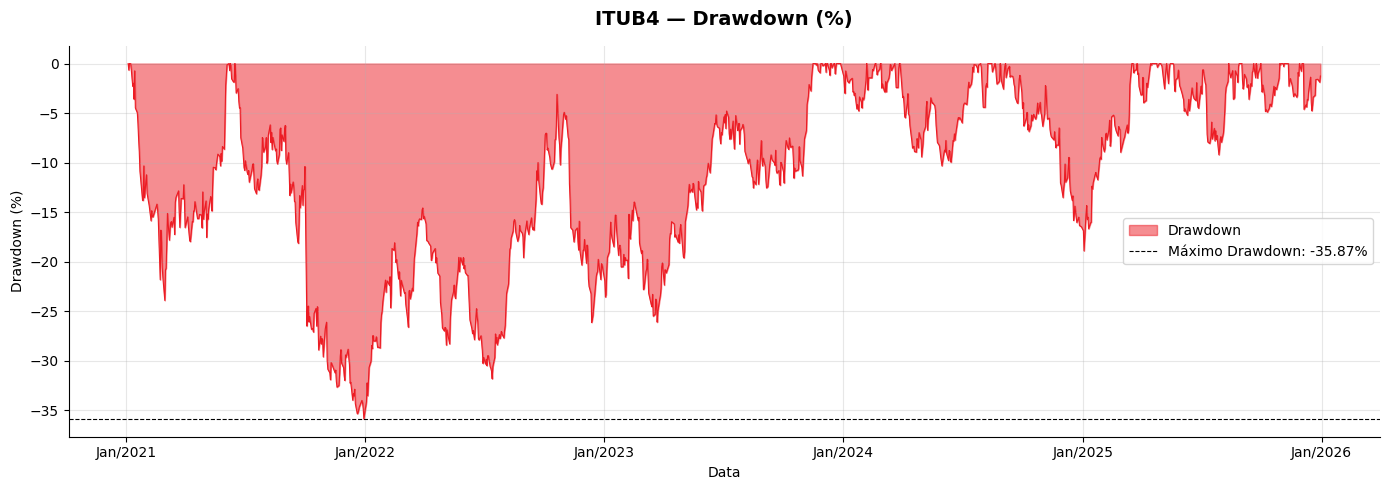


💡 Nota contábil: O drawdown máximo é análogo a uma perda máxima potencial — conceito central em relatórios de risco para o Bacen (RBAN, Nota Explicativa de Risco de Mercado).


In [10]:
# --- Gráfico 4: Drawdown ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(itub4.index, itub4['Drawdown'] * 100, 0,
                alpha=0.5, color=COR_ALERTA, label='Drawdown')
ax.plot(itub4.index, itub4['Drawdown'] * 100, color=COR_ALERTA, lw=0.8)
ax.axhline(max_drawdown * 100, color='black', lw=0.8, linestyle='--',
           label=f'Máximo Drawdown: {max_drawdown:.2%}')

ax.set_title('ITUB4 — Drawdown (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.tight_layout()
plt.savefig('c:/Users/nicol/analise-itau/imagens/grafico_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Nota contábil: O drawdown máximo é análogo a uma perda máxima potencial'
      ' — conceito central em relatórios de risco para o Bacen (RBAN, Nota Explicativa de Risco de Mercado).')
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(itub4.index, itub4['Drawdown'] * 100, 0,
                alpha=0.5, color=COR_ALERTA, label='Drawdown')
ax.plot(itub4.index, itub4['Drawdown'] * 100, color=COR_ALERTA, lw=0.8)
ax.axhline(max_drawdown * 100, color='black', lw=0.8, linestyle='--',
           label=f'Máximo Drawdown: {max_drawdown:.2%}')

ax.set_title('ITUB4 — Drawdown (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.tight_layout()
plt.savefig('c:/Users/nicol/analise-itau/imagens/grafico_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Nota contábil: O drawdown máximo é análogo a uma perda máxima potencial'
      ' — conceito central em relatórios de risco para o Bacen (RBAN, Nota Explicativa de Risco de Mercado).')

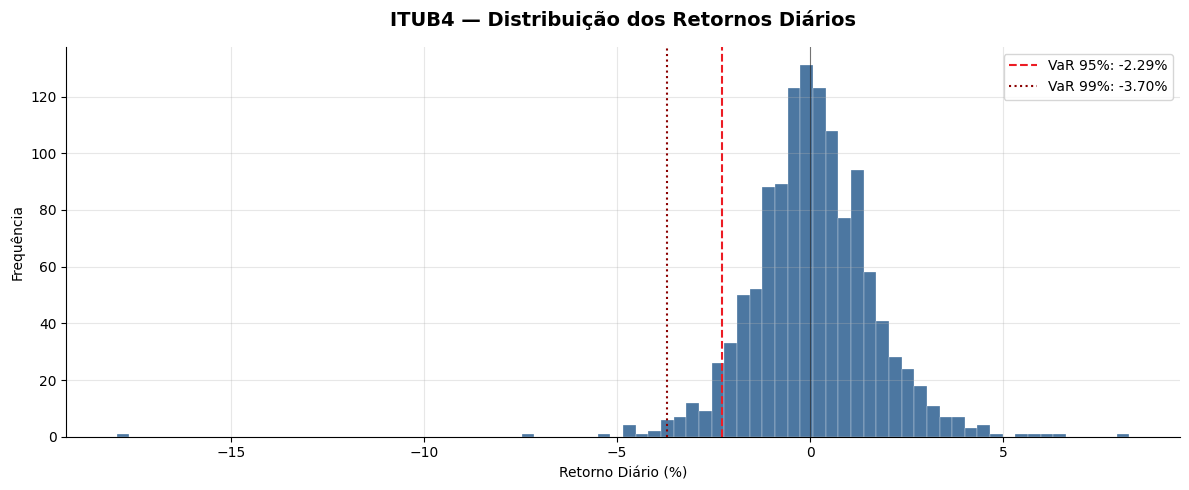

In [11]:
# --- Gráfico 5: Distribuição dos retornos diários ---
fig, ax = plt.subplots(figsize=(12, 5))

retornos = itub4['Retorno_Diario'].dropna() * 100
ax.hist(retornos, bins=80, color=COR_ITAU, alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(var_95 * 100, color=COR_ALERTA, lw=1.5, linestyle='--', label=f'VaR 95%: {var_95:.2%}')
ax.axvline(var_99 * 100, color='darkred',  lw=1.5, linestyle=':',  label=f'VaR 99%: {var_99:.2%}')
ax.axvline(0, color='black', lw=0.8, alpha=0.5)

ax.set_title('ITUB4 — Distribuição dos Retornos Diários', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Retorno Diário (%)')
ax.set_ylabel('Frequência')
ax.legend()

plt.tight_layout()
plt.savefig('c:/Users/nicol/analise-itau/imagens/grafico_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparativo com Benchmarks <a id='6'></a>

Comparar o desempenho de um ativo com seus benchmarks é prática padrão em análise de investimentos. Utilizamos o IBOVESPA (índice de mercado) e a Selic (taxa livre de risco) como referências.

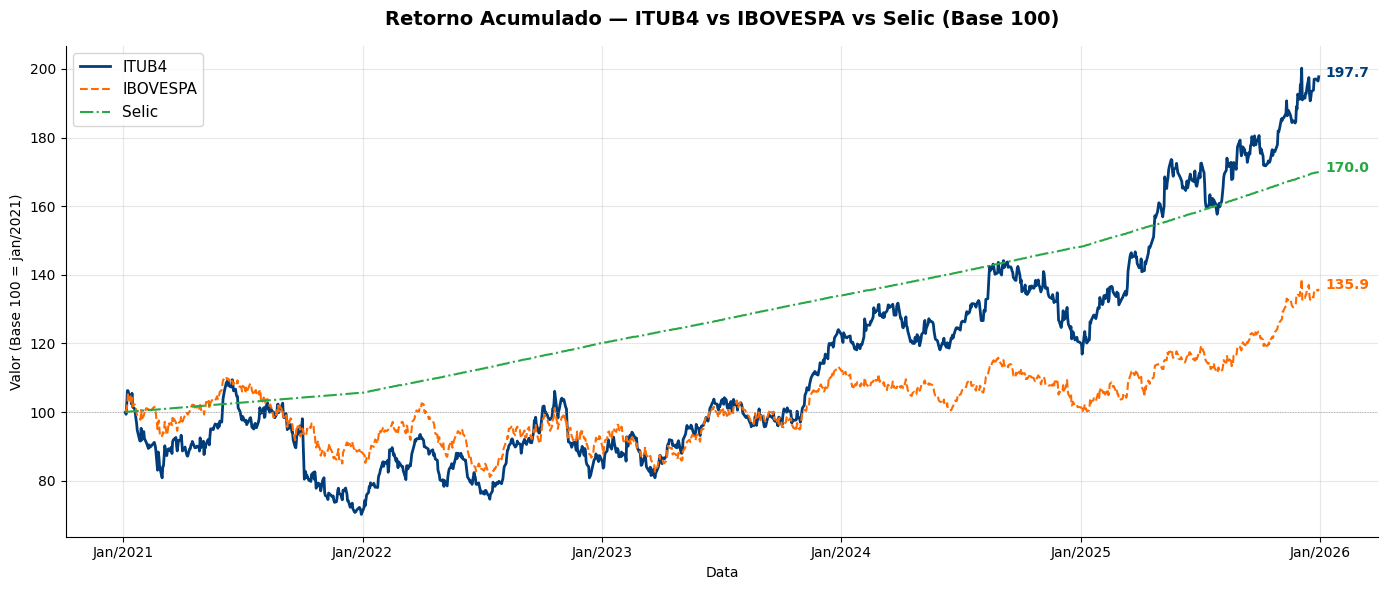


📊 Retorno acumulado no período:
  ITUB4    : 97.7%
  IBOVESPA : 35.9%
  Selic    : 70.0%


In [13]:
# --- Retorno acumulado normalizado (base 100) ---
# Base 100 permite comparar ativos em escalas diferentes
# Sem isso não dá pra comparar direto com base 100, você compara crescimento (%), não preço
base = pd.DataFrame(index=itub4.index) # Cria um novo DataFrame vazio, mas com o mesmo índice datas do itub4.
base['ITUB4'] = (itub4['Close'] / itub4['Close'].iloc[0]) * 100
base['IBOV']  = (ibov['Close']  / ibov['Close'].iloc[0])  * 100

# A Selic é utilizada como referência de retorno de renda fixa.
# Para esta análise, são utilizadas taxas anuais aproximadas por ano,
# convertidas para uma taxa diária considerando 252 dias úteis.
# Esta abordagem é uma aproximação e não representa a série histórica diária oficial da Selic.
taxas_selic = {
    2021: 0.0575, 2022: 0.1375,
    2023: 0.1175, 2024: 0.1065, 2025: 0.1490
}
# Converte a taxa anual de cada ano em uma taxa diária equivalente,
# considerando 252 dias úteis por ano.
# Caso não exista uma taxa específica para determinado ano,
# é utilizada uma taxa aproximada de 10% a.a.
# 📈 Se ITUB4 bate a SELIC
# 📉 Quando renda variável perde para renda fixa
# ⚖️ Comparação risco vs retorno real
selic_diaria_serie = pd.Series(
    [(1 + taxas_selic.get(d.year, 0.10)) ** (1/252) - 1 for d in itub4.index],
    index=itub4.index
)
base['Selic'] = (1 + selic_diaria_serie).cumprod() * 100

# --- Gráfico 6: Comparativo base 100 ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(base.index, base['ITUB4'], color=COR_ITAU,  lw=2,   label='ITUB4')
ax.plot(base.index, base['IBOV'],  color=COR_IBOV,  lw=1.5, label='IBOVESPA', linestyle='--')
ax.plot(base.index, base['Selic'], color=COR_SELIC, lw=1.5, label='Selic', linestyle='-.')
ax.axhline(100, color='gray', lw=0.7, linestyle=':', alpha=0.6)

ax.set_title('Retorno Acumulado — ITUB4 vs IBOVESPA vs Selic (Base 100)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Valor (Base 100 = jan/2021)')
ax.set_xlabel('Data')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

# Anotar retorno final
for col, cor in [('ITUB4', COR_ITAU), ('IBOV', COR_IBOV), ('Selic', COR_SELIC)]:
    val = base[col].iloc[-1]
    ax.annotate(f'{val:.1f}', xy=(base.index[-1], val),
                xytext=(5, 0), textcoords='offset points',
                color=cor, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('c:/Users/nicol/analise-itau/imagens/grafico_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Retorno acumulado no período:')
print(f'  ITUB4    : {base["ITUB4"].iloc[-1] - 100:.1f}%')
print(f'  IBOVESPA : {base["IBOV"].iloc[-1]  - 100:.1f}%')
print(f'  Selic    : {base["Selic"].iloc[-1] - 100:.1f}%')

## 7. Conclusões <a id='7'></a>

In [14]:
# --- Tabela resumo final ---
retorno_itub4 = base['ITUB4'].iloc[-1] - 100
retorno_ibov  = base['IBOV'].iloc[-1]  - 100
retorno_selic = base['Selic'].iloc[-1] - 100

resumo = pd.DataFrame({
    'Métrica': [
        'Retorno Acumulado (2021–2025)',
        'Volatilidade Média Anual',
        'Sharpe Ratio',
        'VaR Diário 95%',
        'Drawdown Máximo'
    ],
    'ITUB4': [
        f'{retorno_itub4:.1f}%',
        f'{itub4["Volatilidade_21d"].mean():.2%}',
        f'{sharpe:.2f}',
        f'{var_95:.2%}',
        f'{max_drawdown:.2%}'
    ]
})

print('=' * 50)
print('        TABELA RESUMO FINAL — ITUB4')
print('=' * 50)
print(resumo.to_string(index=False))
print('=' * 50)
print()
print('✅ Análise concluída! Todos os gráficos foram salvos na pasta imagens.')

        TABELA RESUMO FINAL — ITUB4
                      Métrica   ITUB4
Retorno Acumulado (2021–2025)   97.7%
     Volatilidade Média Anual  23.77%
                 Sharpe Ratio    0.26
               VaR Diário 95%  -2.29%
              Drawdown Máximo -35.87%

✅ Análise concluída! Todos os gráficos foram salvos na pasta imagens.
